# Práctica 1B: Cálculo de frecuencias a nivel de palabra

## Realizado por: Eduardo Alanís García

### Cargar google drive

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verificar existencia de los archivos

In [87]:
import os

direccion = "/content/drive/MyDrive/MCDI-INFOTEC/1. Primer semestre/Manejo y procesamiento de la informacion/Unidad 1/Práctica 1B Cálculo de frecuencias a nivel de palabra/"

archivos = ["libro_1.txt", "libro_2.txt"]

for archivo in archivos:
  ruta = os.path.join(direccion, archivo)
  print(archivo, "Existe" if os.path.exists(ruta) else "No Existe")

libro_1.txt Existe
libro_2.txt Existe


### Función leer archivos

In [88]:
def leer_archivo(nombre_archivo, direccion=direccion):
  ruta = os.path.join(direccion, nombre_archivo)

  with open(ruta, "r", encoding="utf-8") as f:
      texto = f.read()

  return texto

### Función de quitar acentos

In [89]:
import unicodedata

def remove_accents(input_str):
  nfkd_form = unicodedata.normalize('NFKD', input_str)
  return u"".join([c for c in nfkd_form if not unicodedata.combining(c)])

### Caracteres a eliminar

In [90]:
caracteres_eliminar = ";:,.\\-\"'/()[]¿?¡!{}~<>|«»-—’"

### Función preprocesar texto

In [91]:
def preprocesar_texto(texto):
  texto = texto.lower()  # Minusculas
  texto = remove_accents(texto)  # Acentos
  texto = texto.replace('\t', ' ').replace('\n', ' ')  # Tabulaciones y saltos de linea

  for c in caracteres_eliminar:
    #print("Caracter: ", c, end="\n")
    texto = texto.replace(c, '')  # Eliminar caracteres mencionados

  return texto

### Función calculo de frecuencias

In [92]:
from collections import Counter

def calcular_frecuencias(texto):
  palabras = texto.split()
  frecuencias = Counter(palabras)
  ordenado = frecuencias.most_common()

  palabras = []
  valores = []

  for palabra, frecuencia in ordenado:
      palabras.append(palabra)
      valores.append(frecuencia)

  guardar = {
      "palabras": palabras,
      "valores": valores
  }

  return guardar

### Generar los resultados

In [93]:
resultados = {}

for archivo in archivos:
  texto_original = leer_archivo(nombre_archivo=archivo)
  texto_procesado = preprocesar_texto(texto=texto_original)
  frecuencias = calcular_frecuencias(texto=texto_procesado)

  resultados[archivo] = {
      "texto_original": texto_original,
      "texto_procesado": texto_procesado,
      "frecuencias": frecuencias
  }

### Preguntas

In [94]:
for archivo in archivos:
  texto = resultados[archivo]["texto_procesado"]
  palabras = texto.split()

  valores = resultados[archivo]["frecuencias"]["valores"]

  cantidad_palabras = len(palabras)
  palabras_diferentes = len(valores)

  hapax = 0

  for frecuencia in valores:
      if frecuencia == 1:
          hapax += 1

  print("Archivo:", archivo)
  print("¿Cuántas palabras hay en cada texto?", cantidad_palabras)
  print("¿Cuántas palabras diferentes (palabras únicas) hay en el texto?", palabras_diferentes)
  print("¿Cuántas son las palabras con frecuencia 1 (hapax legomena) en el texto?", hapax)
  print("\n")


Archivo: libro_1.txt
¿Cuántas palabras hay en cada texto? 56820
¿Cuántas palabras diferentes (palabras únicas) hay en el texto? 7789
¿Cuántas son las palabras con frecuencia 1 (hapax legomena) en el texto? 4700


Archivo: libro_2.txt
¿Cuántas palabras hay en cada texto? 50540
¿Cuántas palabras diferentes (palabras únicas) hay en el texto? 8497
¿Cuántas son las palabras con frecuencia 1 (hapax legomena) en el texto? 5214




### Función general graficas

In [95]:
import matplotlib.pyplot as plt

def graficar_histograma(resultados, titulo):
  palabras = resultados[titulo]["frecuencias"]["palabras"]
  valores = resultados[titulo]["frecuencias"]["valores"]

  # Solo 20 primeras
  palabras = palabras[:20]
  valores = valores[:20]

  plt.figure(figsize=(16, 6))

  barras = plt.bar(palabras, valores)

  plt.title(titulo)
  plt.xlabel('Palabra')
  plt.ylabel('Frecuencia')
  plt.xticks(rotation=90)

  plt.bar_label(barras, padding=3) # Valor encima de cada barra

  plt.tight_layout()
  plt.show()

### Graficas

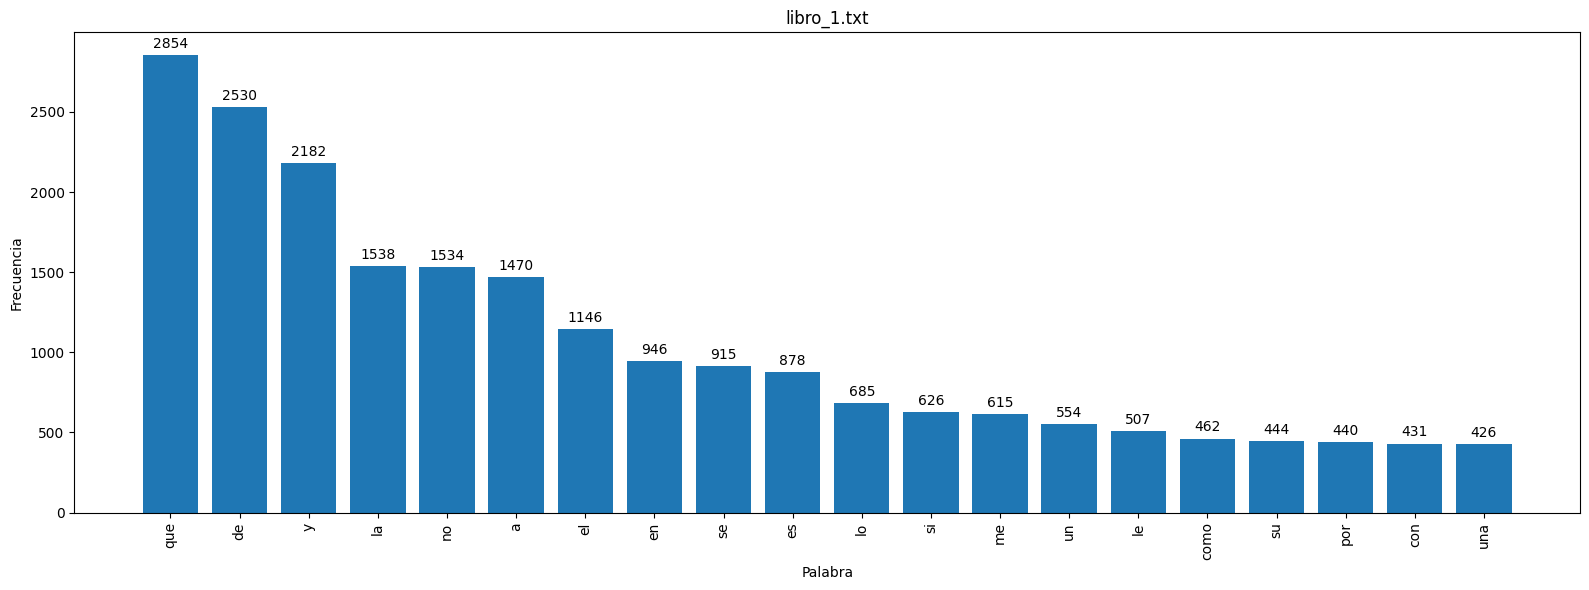

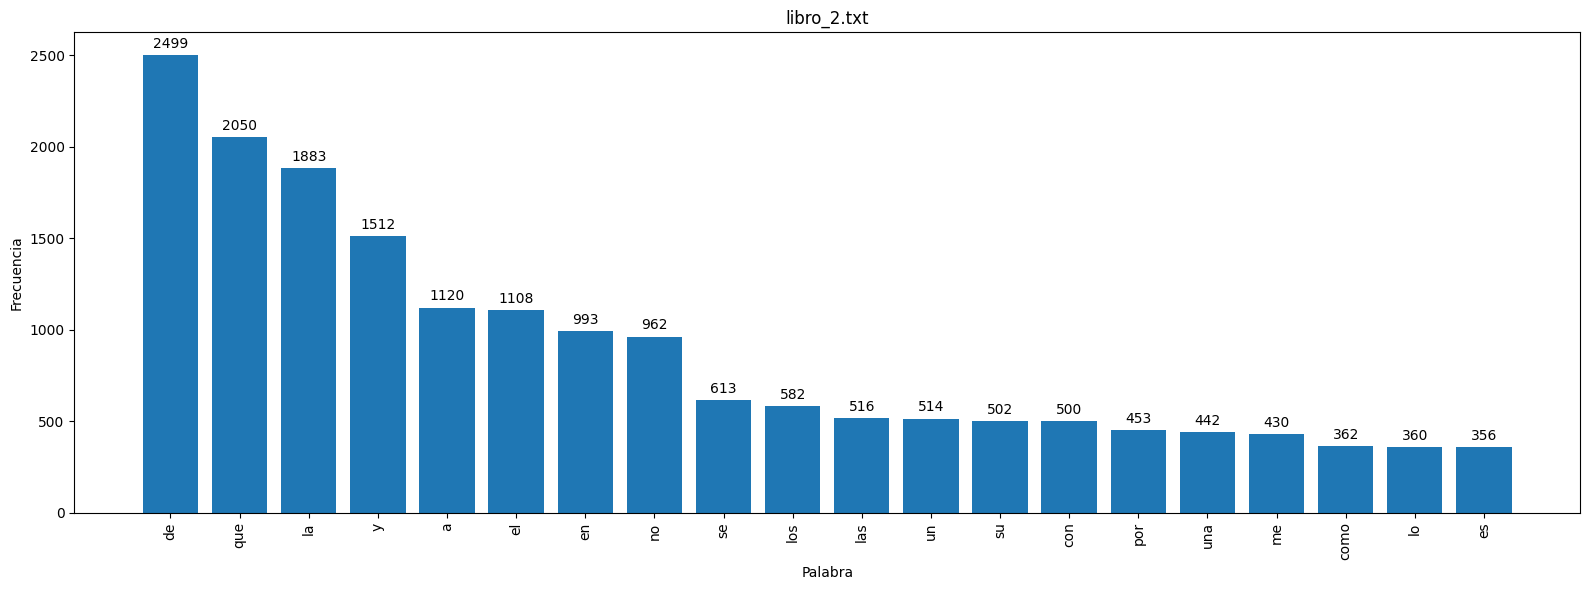

In [96]:
for archivo in archivos:
  graficar_histograma(resultados, archivo)